In [10]:
import joblib
import os

# 加载 pkl 文件
pkl_path = "data/new_robot/amass_all.pkl"
# pkl_path = "data/new_robot/test.pkl"
# pkl_path = "data/h1/amass_phc_filtered.pkl"
if not os.path.exists(pkl_path):
    raise FileNotFoundError(f"{pkl_path} not found!")

data = joblib.load(pkl_path)
print(f"✅ 成功载入 {pkl_path}")
print(f"📦 动作数量: {len(data)}\n")

# # 遍历所有 motion 并打印结构信息
# for idx, motion_key in enumerate(data.keys()):
#     motion_data = data[motion_key]
#     print(type(motion_data))
#     print(f"🕺 Motion [{idx+1}/{len(data)}]: {motion_key}")
#     for field in motion_data:
#         array = motion_data[field]
#         if hasattr(array, "shape"):
#             print(f"   ├─ {field:<20}: shape = {array.shape}, dtype = {array.dtype}")
#         else:
#             print(f"   ├─ {field:<20}: {array}")
#     print()
#     if idx >= 0:  # 限制输出前5个动作
#         break

for idx, (motion_key, motion_data) in enumerate(data.items()):
    print(f"🕺 Motion [{idx+1}/{len(data)}]: {motion_key}")
    # frames = motion_data["frames"]
    # for i, frame in enumerate(frames):
    #     elbow_pos = frame["left_shoulder_local"]["tcp_pos"]
    #     tcp_pos = frame["left_shoulder_local"]["tcp_pos"]
        # print(f"  Frame {i}:")
        # print(f"    Left Elbow Pos: {elbow_pos}")
        # print(f"    Left TCP Pos  : {tcp_pos}")


✅ 成功载入 data/new_robot/amass_all.pkl
📦 动作数量: 23

🕺 Motion [1/23]: 0-ACCAD_Female1General_c3d_A6- lift box t2_poses
🕺 Motion [2/23]: 0-ACCAD_Female1General_c3d_A11 - crawl forward_poses
🕺 Motion [3/23]: 0-ACCAD_Female1General_c3d_A8 - crouch to lie_poses
🕺 Motion [4/23]: 0-ACCAD_Female1General_c3d_A2 - Sway t2_poses
🕺 Motion [5/23]: 0-ACCAD_Female1General_c3d_A10 - lie to crouch_poses
🕺 Motion [6/23]: 0-ACCAD_Female1General_c3d_A3 - Swing_poses
🕺 Motion [7/23]: 0-ACCAD_Female1General_c3d_A4 - look_poses
🕺 Motion [8/23]: 0-ACCAD_Female1General_c3d_A3 - Swing t2_poses
🕺 Motion [9/23]: 0-ACCAD_Female1General_c3d_A2 - Sway_poses
🕺 Motion [10/23]: 0-ACCAD_Female1General_c3d_A14 - stand to skip_poses
🕺 Motion [11/23]: 0-ACCAD_Female1General_c3d_A6 - lift box_poses
🕺 Motion [12/23]: 0-ACCAD_Female1General_c3d_A1 - Stand_poses
🕺 Motion [13/23]: 0-ACCAD_Female1General_c3d_A9 - lie t2_poses
🕺 Motion [14/23]: 0-ACCAD_Female1General_c3d_A15 - skip to stand_poses
🕺 Motion [15/23]: 0-ACCAD_Female1Gene

In [25]:
import joblib
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 加载 pkl 文件
pkl_path = "gym_hand_elbow_trajectory_test.pkl"
if not os.path.exists(pkl_path):
    raise FileNotFoundError(f"{pkl_path} not found!")

data = joblib.load(pkl_path)
print(data[0]['left_hand'])
print(data[240]['left_hand'])
print(f"✅ 成功载入 {pkl_path}")
print(f"📦 动作数量: {len(data)}\n")

# 提取左手 TCP 坐标
for idx, (motion_key, motion_data) in enumerate(data.items()):
    print(f"🕺 Motion [{idx+1}/{len(data)}]: {motion_key}")
    frames = motion_data["frames"]

    tcp_positions = []
    for frame in frames:
        tcp_pos = frame["left_shoulder_local"]["tcp_pos"]  # shape: (3,)
        tcp_positions.append(tcp_pos)

    tcp_positions = np.array(tcp_positions)  # shape: (N, 3)

    # ========================
    # 🎥 绘制3D轨迹图
    # ========================
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot(
        tcp_positions[:, 0],
        tcp_positions[:, 1],
        tcp_positions[:, 2],
        label='Left TCP Trajectory',
        color='green'
    )

    ax.set_title("Left TCP Trajectory (Local Coordinates)")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.legend()

    plt.tight_layout()
    plt.show()
    break  # 只画第一个 motion 的 TCP 轨迹


[-0.48533696  0.547312    1.151343  ]
[-0.34275663  0.46404374  1.9046688 ]
✅ 成功载入 gym_hand_elbow_trajectory_test.pkl
📦 动作数量: 481



AttributeError: 'list' object has no attribute 'items'

✅ 成功载入 data/h1/amass_all.pkl, 动作数量: 252
(213, 19)
🎬 0-ACCAD_Female1General_c3d_A6- lift box t2_poses - 帧数: 213, 左肘值范围: [-0.48, 1.27]


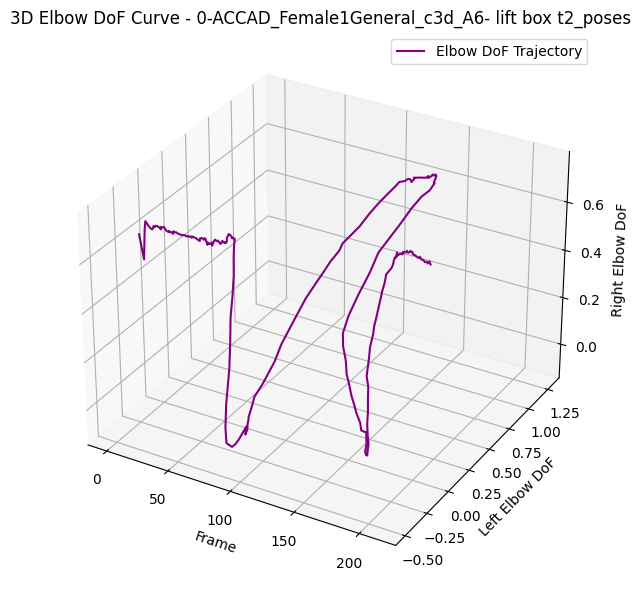


📊 所有动作中肘部 DoF 统计：
   左肘: shape = (213,), min = -0.479, max = 1.275
   右肘: shape = (213,), min = -0.127, max = 0.787


In [11]:
# 提取Dof并绘制

import joblib
import os
import numpy as np

ALL_KEY_FLAG = False

# 加载数据
pkl_path = "data/h1/amass_all.pkl"
data = joblib.load(pkl_path)
print(f"✅ 成功载入 {pkl_path}, 动作数量: {len(data)}")

# 定义左右肘关节在 humanoid dof 中的索引
# 参照 H1 humanoid: dof[13] = left_elbow, dof[18] = right_elbow
LEFT_ELBOW_IDX = 13
RIGHT_ELBOW_IDX = 18

# 用于保存所有肘部轨迹
left_elbow_all = []
right_elbow_all = []

for key in data:
    dof = data[key]["dof"]  # shape: (N, 19)
    print(dof.shape)
    
    left_elbow = dof[:, LEFT_ELBOW_IDX]   # shape: (N,)
    right_elbow = dof[:, RIGHT_ELBOW_IDX] # shape: (N,)
    
    left_elbow_all.append(left_elbow)
    right_elbow_all.append(right_elbow)

    print(f"🎬 {key} - 帧数: {len(left_elbow)}, 左肘值范围: [{left_elbow.min():.2f}, {left_elbow.max():.2f}]")

    if not ALL_KEY_FLAG:
        # 绘制3D肘部运动轨迹
        fig = plt.figure(figsize=(10, 6))
        ax = fig.add_subplot(111, projection='3d')
        ax.plot(frames, left_elbow, right_elbow, label='Elbow DoF Trajectory', color='purple')

        ax.set_xlabel('Frame')
        ax.set_ylabel('Left Elbow DoF')
        ax.set_zlabel('Right Elbow DoF')
        ax.set_title(f'3D Elbow DoF Curve - {key}')
        ax.legend()
        plt.tight_layout()
        plt.show()
        break
# 可选：合并所有轨迹作为整体分析
left_elbow_all = np.concatenate(left_elbow_all)
right_elbow_all = np.concatenate(right_elbow_all)

print("\n📊 所有动作中肘部 DoF 统计：")
print(f"   左肘: shape = {left_elbow_all.shape}, min = {left_elbow_all.min():.3f}, max = {left_elbow_all.max():.3f}")
print(f"   右肘: shape = {right_elbow_all.shape}, min = {right_elbow_all.min():.3f}, max = {right_elbow_all.max():.3f}")


2025-07-28 16:37:38,528 - INFO - logger - logger initialized


✅ 成功载入 data/h1/amass_all.pkl, 动作数量: 252

🎬 处理动作: 0-ACCAD_Female1General_c3d_A6- lift box t2_poses
🤖 左肘轨迹: shape = (213, 3)
🤖 右肘轨迹: shape = (213, 3)


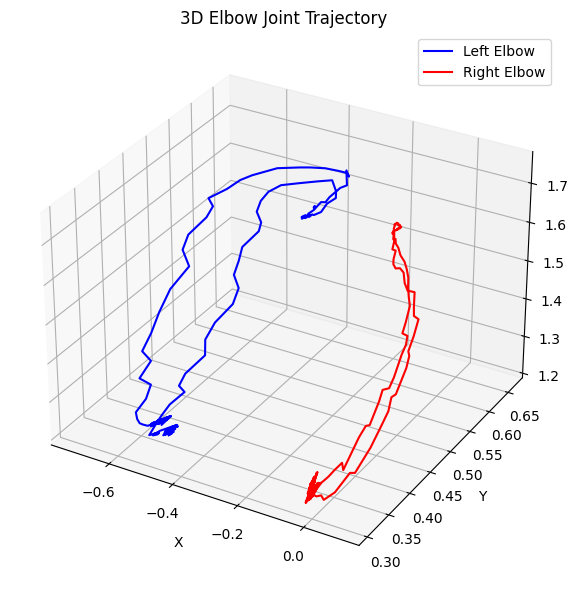

In [10]:
# 绘制amass_all.pkl中的肘部轨迹，依据pose_aa和root_trans_offset计算关节3D位置，然后提取肘关节轨迹

import joblib
import numpy as np
import torch
from phc.utils.torch_h1_humanoid_batch import Humanoid_Batch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 加载数据
pkl_path = "data/h1/amass_all.pkl"
data = joblib.load(pkl_path)
print(f"✅ 成功载入 {pkl_path}, 动作数量: {len(data)}")

# 初始化 FK 模块
h1_fk = Humanoid_Batch(device=device)

# 左右肘关节在 H1 humanoid 中的索引（包含扩展关节）
H1_JOINT_NAMES = [ 'pelvis', 
                    'left_hip_yaw_link', 'left_hip_roll_link','left_hip_pitch_link', 'left_knee_link', 'left_ankle_link',
                    'right_hip_yaw_link', 'right_hip_roll_link', 'right_hip_pitch_link', 'right_knee_link', 'right_ankle_link',
                    'torso_link', 'left_shoulder_pitch_link', 'left_shoulder_roll_link', 'left_shoulder_yaw_link', 'left_elbow_link', 
                    'right_shoulder_pitch_link', 'right_shoulder_roll_link', 'right_shoulder_yaw_link', 'right_elbow_link']
LEFT_ELBOW_IDX = H1_JOINT_NAMES.index("left_elbow_link")
RIGHT_ELBOW_IDX = H1_JOINT_NAMES.index("right_elbow_link")

# 只提取第一个数据项
first_key = list(data.keys())[0]
motion = data[first_key]
print(f"\n🎬 处理动作: {first_key}")

pose_aa = torch.tensor(motion["pose_aa"]).unsqueeze(0).float().to(device)       # shape: (1, N, 22, 3)
root_trans = torch.tensor(motion["root_trans_offset"]).unsqueeze(0).float().to(device)  # shape: (1, N, 3)

# 前向运动学得到所有关节3D位置
with torch.no_grad():
    fk_result = h1_fk.fk_batch(pose_aa, root_trans)

joints_3d = fk_result["global_translation_extend"].squeeze(0).cpu().numpy()  # shape: (N, 22, 3)

# 提取肘关节轨迹
left_elbow_pos = joints_3d[:, LEFT_ELBOW_IDX, :]   # shape: (N, 3)
right_elbow_pos = joints_3d[:, RIGHT_ELBOW_IDX, :] # shape: (N, 3)

print(f"🤖 左肘轨迹: shape = {left_elbow_pos.shape}")
print(f"🤖 右肘轨迹: shape = {right_elbow_pos.shape}")

# 可视化
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

frames = np.arange(left_elbow_pos.shape[0])
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(left_elbow_pos[:, 0], left_elbow_pos[:, 1], left_elbow_pos[:, 2], label='Left Elbow', color='blue')
ax.plot(right_elbow_pos[:, 0], right_elbow_pos[:, 1], right_elbow_pos[:, 2], label='Right Elbow', color='red')

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("3D Elbow Joint Trajectory")
ax.legend()
plt.tight_layout()
plt.show()


✅ 成功载入 gym_hand_elbow_trajectory_test.pkl，帧数：481


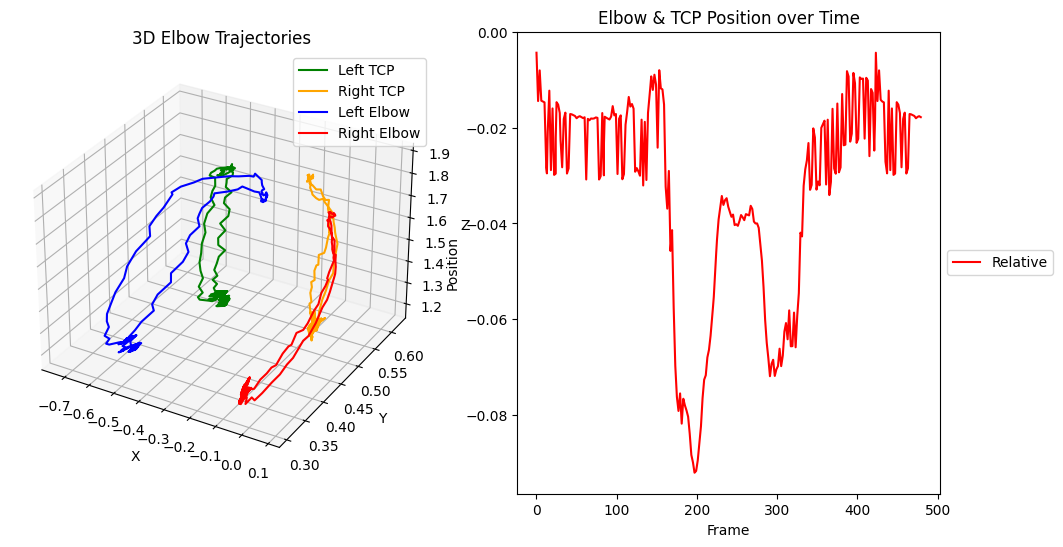

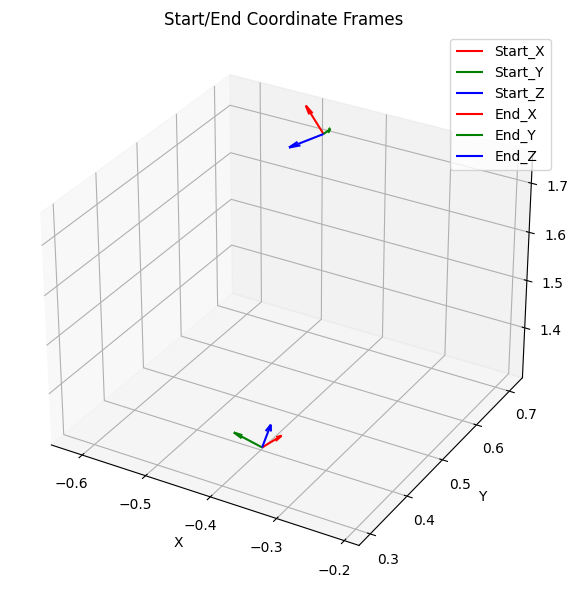

In [ ]:
# 绘制vis_motion.py中，IsaacGym中记录的肘部轨迹
import joblib
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from scipy.spatial.transform import Rotation as R

def draw_coordinate_frame(ax, origin, quat_wxyz, length=0.1, label=""):
    """绘制一个小坐标系：X红，Y绿，Z蓝"""
    # 将 wxyz 转成 scipy Rotation
    rot = R.from_quat([quat_wxyz[1], quat_wxyz[2], quat_wxyz[3], quat_wxyz[0]])
    axes = rot.apply(np.eye(3)) * length
    colors = ['r', 'g', 'b']
    for i in range(3):
        ax.quiver(
            origin[0], origin[1], origin[2],
            axes[i, 0], axes[i, 1], axes[i, 2],
            color=colors[i], label=f"{label}_{['X','Y','Z'][i]}"
        )

def set_axes_equal(ax):
    """设置3D图为等比例坐标轴，确保箭头方向正确呈现"""
    limits = np.array([
        ax.get_xlim3d(),
        ax.get_ylim3d(),
        ax.get_zlim3d(),
    ])
    spans = limits[:,1] - limits[:,0]
    centers = np.mean(limits, axis=1)
    radius = 0.3 * max(spans)
    for ctr, axis in zip(centers, [ax.set_xlim3d, ax.set_ylim3d, ax.set_zlim3d]):
        axis([ctr - radius, ctr + radius])

# 加载数据
pkl_path = "gym_hand_elbow_trajectory_test.pkl"
data = joblib.load(pkl_path)
print(f"✅ 成功载入 {pkl_path}，帧数：{len(data)}")

# 提取左右肘位置和帧数
frames = []
left_elbows = []
right_elbows = []
left_tcps = []
right_tcps = []
for item in data:
    frames.append(item["frame"])
    left_tcps.append(item["left_hand"])
    right_tcps.append(item["right_hand"])
    left_elbows.append(item["left_elbow"])
    right_elbows.append(item["right_elbow"])

frames = np.array(frames)
left_tcps = np.array(left_tcps)   # shape: (N, 3)
right_tcps = np.array(right_tcps) # shape: (N, 3)
left_elbows = np.array(left_elbows)   # shape: (N, 3)
right_elbows = np.array(right_elbows) # shape: (N, 3)
medium_len = len(left_tcps)//2

# ========================
# 🎥 1. 绘制3D轨迹图
# ========================``
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(121, projection='3d')

ax.plot(left_tcps[:, 0], left_tcps[:, 1], left_tcps[:, 2], label='Left TCP', color='green')
ax.plot(right_tcps[:, 0], right_tcps[:, 1], right_tcps[:, 2], label='Right TCP', color='orange')
ax.plot(left_elbows[:, 0], left_elbows[:, 1], left_elbows[:, 2], label='Left Elbow', color='blue')
ax.plot(right_elbows[:, 0], right_elbows[:, 1], right_elbows[:, 2], label='Right Elbow', color='red')

ax.set_title("3D Elbow Trajectories")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()

# ========================
# 📈 2. 绘制各坐标分量随时间变化曲线
# ========================
ax2 = fig.add_subplot(122)

# Left Elbow
# ax2.plot(frames, left_elbows[:, 0], label='Left Elbow X', color='blue')
# ax2.plot(frames, left_elbows[:, 1], label='Left Elbow Y', color='cyan')
# ax2.plot(frames, left_elbows[:, 2], label='Left Elbow Z', color='navy')
# Right Elbow
# ax2.plot(frames, right_elbows[:, 0], label='Right Elbow X', color='red')
# ax2.plot(frames, right_elbows[:, 1], label='Right Elbow Y', color='orange')
# ax2.plot(frames, right_elbows[:, 2], label='Right Elbow Z', color='darkred')
# Left TCP
# ax2.plot(frames, left_tcps[:, 0], label='Left TCP X', color='green')
# ax2.plot(frames, left_tcps[:, 1], label='Left TCP Y', color='lime')
# ax2.plot(frames, left_tcps[:, 2], label='Left TCP Z', color='darkgreen')
# Right TCP
# ax2.plot(frames, right_tcps[:, 0], label='Right TCP X', color='brown')
# ax2.plot(frames, right_tcps[:, 1], label='Right TCP Y', color='sandybrown')
# ax2.plot(frames, right_tcps[:, 2], label='Right TCP Z', color='yellow')
ax2.plot(frames, right_tcps[:, 0] - right_elbows[:, 0], label='Relative', color='red')

ax2.set_title("Elbow & TCP Position over Time")
ax2.set_xlabel("Frame")
ax2.set_ylabel("Position")
ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# ========================
# 📈 3. 绘制起点和终点的坐标系
# ========================
fig2 = plt.figure(figsize=(6, 6))
ax3d = fig2.add_subplot(111, projection='3d')

# 提取位置与四元数旋转（wxyz）
start_tcp_pos = data[0]["left_hand"]                     # 起始 TCP 位置
start_tcp_rot = data[0]["left_hand_rot"]                 # 起始 TCP 姿态（wxyz）

end_tcp_pos = data[medium_len]["left_hand"]
end_tcp_rot = data[medium_len]["left_hand_rot"]

# 绘制坐标系
draw_coordinate_frame(ax3d, start_tcp_pos, start_tcp_rot, length=0.05, label="Start")
draw_coordinate_frame(ax3d, end_tcp_pos, end_tcp_rot, length=0.05, label="End")
set_axes_equal(ax3d)

ax3d.set_title("Start/End Coordinate Frames")
ax3d.set_xlabel("X")
ax3d.set_ylabel("Y")
ax3d.set_zlabel("Z")
ax3d.legend()
plt.tight_layout()
plt.show()



✅ 成功载入 get_6D_pose_hand_elbow_trajectory_test.pkl，共 20 个 motion
left_tcps 0: [-0.1693896   0.34124279  0.08345753]


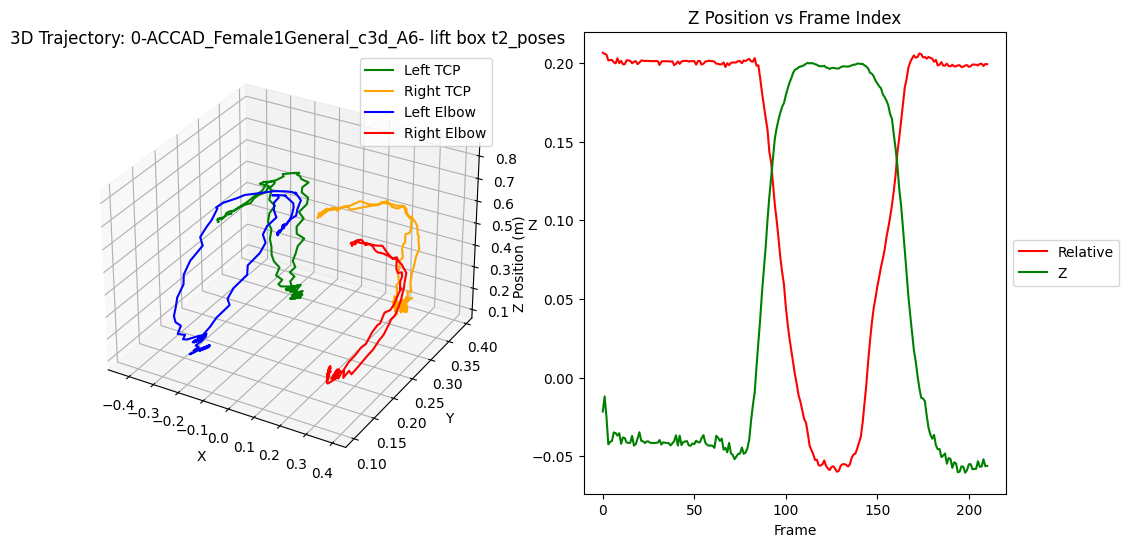

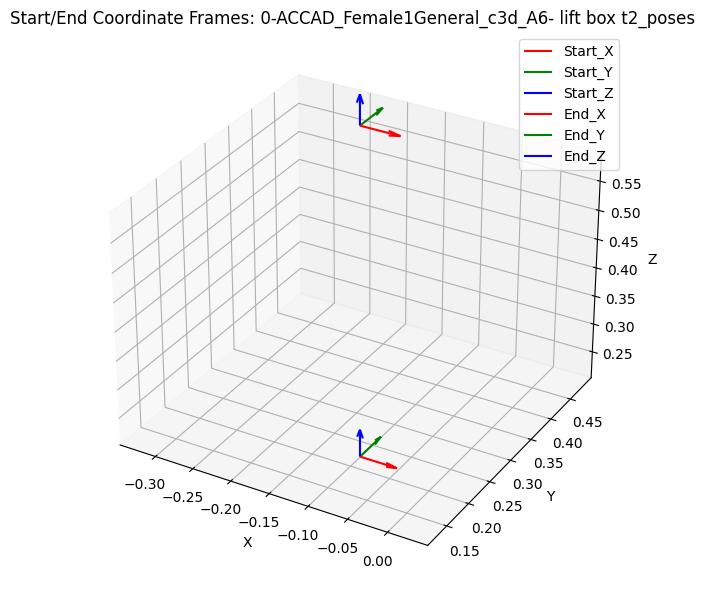

<Figure size 640x480 with 0 Axes>

In [34]:
# 绘制get_6D_pose_hand_elbow_trajectory_test.pkl中的手肘轨迹
# visualize_hand_elbow_trajectory.py

import joblib
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from scipy.spatial.transform import Rotation as R

def draw_coordinate_frame(ax, origin, quat_wxyz, length=0.1, label=""):
    """绘制一个小坐标系：X红，Y绿，Z蓝"""
    # 将 wxyz 转成 scipy Rotation
    rot = R.from_quat([quat_wxyz[1], quat_wxyz[2], quat_wxyz[3], quat_wxyz[0]])
    axes = rot.apply(np.eye(3)) * length
    colors = ['r', 'g', 'b']
    for i in range(3):
        ax.quiver(
            origin[0], origin[1], origin[2],
            axes[i, 0], axes[i, 1], axes[i, 2],
            color=colors[i], label=f"{label}_{['X','Y','Z'][i]}"
        )

def set_axes_equal(ax):
    """设置3D图为等比例坐标轴，确保箭头方向正确呈现"""
    limits = np.array([
        ax.get_xlim3d(),
        ax.get_ylim3d(),
        ax.get_zlim3d(),
    ])
    spans = limits[:,1] - limits[:,0]
    centers = np.mean(limits, axis=1)
    radius = 0.3 * max(spans)
    for ctr, axis in zip(centers, [ax.set_xlim3d, ax.set_ylim3d, ax.set_zlim3d]):
        axis([ctr - radius, ctr + radius])

# ==== 配置 ====
pkl_path = "get_6D_pose_hand_elbow_trajectory_test.pkl"
motion_key = None  # 设为 None 表示默认读取第一个 motion；或填 "0-ACCAD_Female1General_c3d_A6- lift box t2_poses"

# ==== 加载数据 ====
data = joblib.load(pkl_path)
print(f"✅ 成功载入 {pkl_path}，共 {len(data)} 个 motion")

# ==== 选择一个 motion ====
if motion_key is None:
    motion_key = list(data.keys())[0]

assert motion_key in data, f"❌ motion_key={motion_key} 不存在！"

motion = data[motion_key]
frames = motion["frames"]

left_tcps = []
right_tcps = []
left_elbows = []
right_elbows = []
frame_indices = []

for frame in frames:
    frame_indices.append(frame["frame"])
    left_tcps.append(frame["left_root"]["tcp_pos"])
    right_tcps.append(frame["right_root"]["tcp_pos"])
    left_elbows.append(frame["left_root"]["elbow_pos"])
    right_elbows.append(frame["right_root"]["elbow_pos"])

left_tcps = np.array(left_tcps)
right_tcps = np.array(right_tcps)
left_elbows = np.array(left_elbows)
right_elbows = np.array(right_elbows)
frame_indices = np.array(frame_indices)
medium_len = len(left_tcps)//2

print("left_tcps 0:", left_tcps[0])

# ========================
# 🎥 1. 绘制3D轨迹图
# ========================
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(121, projection='3d')

ax.plot(left_tcps[:, 0], left_tcps[:, 1], left_tcps[:, 2], label='Left TCP', color='green')
ax.plot(right_tcps[:, 0], right_tcps[:, 1], right_tcps[:, 2], label='Right TCP', color='orange')
ax.plot(left_elbows[:, 0], left_elbows[:, 1], left_elbows[:, 2], label='Left Elbow', color='blue')
ax.plot(right_elbows[:, 0], right_elbows[:, 1], right_elbows[:, 2], label='Right Elbow', color='red')

ax.set_title(f"3D Trajectory: {motion_key}")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()

# ========================
# 📈 2. 绘制 Z 分量随时间变化曲线
# ========================
ax2 = fig.add_subplot(122)

# ax2.plot(frame_indices, left_tcps[:, 2], label='Left TCP Z', color='green')
# ax2.plot(frame_indices, right_tcps[:, 2], label='Right TCP Z', color='orange')
# ax2.plot(frame_indices, left_elbows[:, 2], label='Left Elbow Z', color='blue')
# ax2.plot(frame_indices, right_elbows[:, 2], label='Right Elbow Z', color='red')

ax2.plot(frame_indices, right_tcps[:, 1] - right_elbows[:, 1], label='Relative', color='red')
ax2.plot(frame_indices, right_tcps[:, 2] - right_elbows[:, 2], label='Z', color='green')

ax2.set_title("Z Position vs Frame Index")
ax2.set_xlabel("Frame")
ax2.set_ylabel("Z Position (m)")
ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# ========================
# 📈 3. 绘制起点和终点的坐标系
# ========================
fig2 = plt.figure(figsize=(6, 6))
ax3d = fig2.add_subplot(111, projection='3d')

# 获取起点/终点的 TCP 位姿（从 frame 中读取）
start_tcp_pos = frames[0]["left_root"]["tcp_pos"]
start_tcp_rot = frames[0]["left_root"]["tcp_rot"]  # wxyz 四元数
end_tcp_pos = frames[medium_len]["left_root"]["tcp_pos"]
end_tcp_rot = frames[medium_len]["left_root"]["tcp_rot"]  # wxyz 四元数

# 绘制坐标系
draw_coordinate_frame(ax3d, start_tcp_pos, start_tcp_rot, length=0.05, label="Start")
draw_coordinate_frame(ax3d, end_tcp_pos, end_tcp_rot, length=0.05, label="End")
set_axes_equal(ax3d)

ax3d.set_title(f"Start/End Coordinate Frames: {motion_key}")
ax3d.set_xlabel("X")
ax3d.set_ylabel("Y")
ax3d.set_zlabel("Z")
ax3d.legend()
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()


✅ 成功载入 data/new_robot/amass_all.pkl，共 23 个 motion
(213, 3)
106
left_tcps 0: [-0.14381668  0.42531131  0.05330375]
left_tcps [-0.10605732  0.28645119  0.77808017]


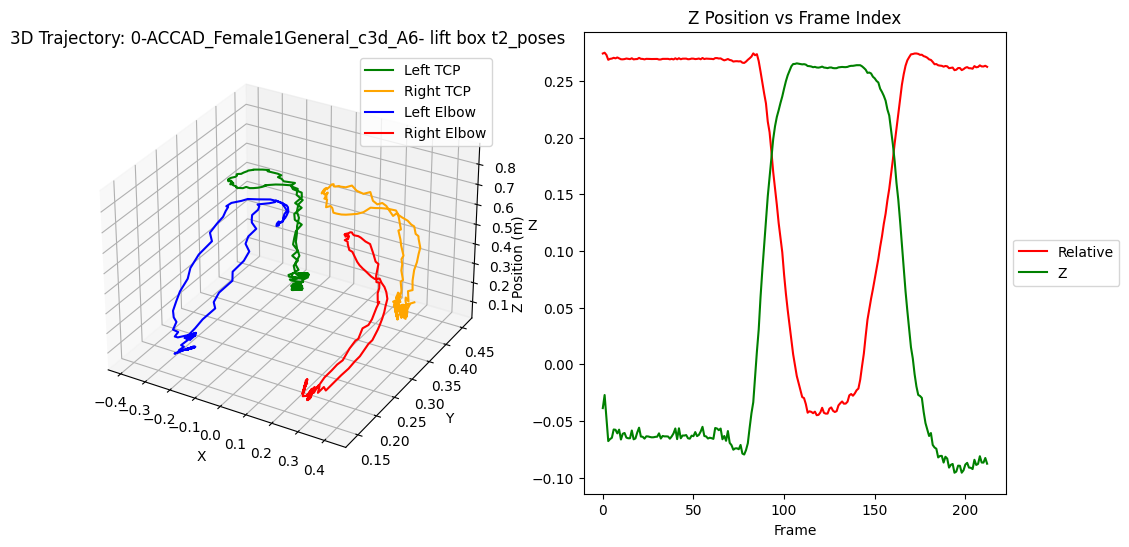

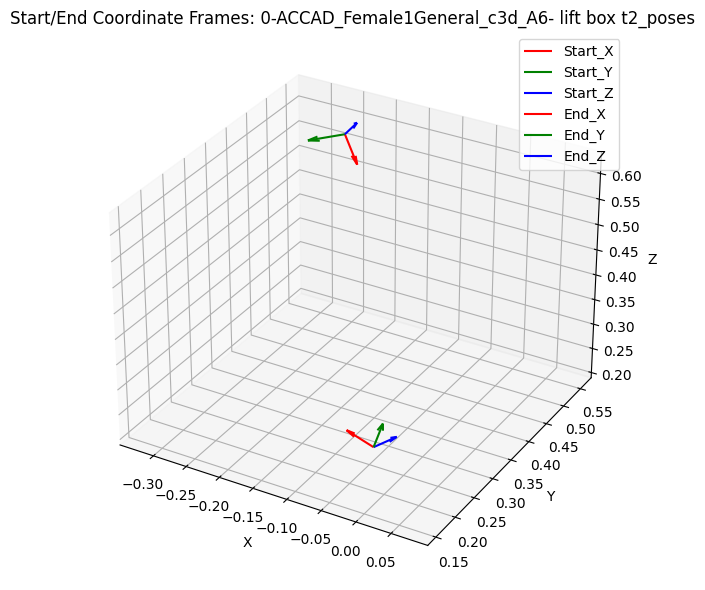

<Figure size 640x480 with 0 Axes>

In [46]:
# 绘制amass_all.pkl中的手肘轨迹
# visualize_hand_elbow_trajectory.py

import joblib
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from scipy.spatial.transform import Rotation as R

def draw_coordinate_frame(ax, origin, quat_wxyz, length=0.1, label=""):
    """绘制一个小坐标系：X红，Y绿，Z蓝"""
    # 将 wxyz 转成 scipy Rotation
    rot = R.from_quat([quat_wxyz[1], quat_wxyz[2], quat_wxyz[3], quat_wxyz[0]])
    axes = rot.apply(np.eye(3)) * length
    colors = ['r', 'g', 'b']
    for i in range(3):
        ax.quiver(
            origin[0], origin[1], origin[2],
            axes[i, 0], axes[i, 1], axes[i, 2],
            color=colors[i], label=f"{label}_{['X','Y','Z'][i]}"
        )

def set_axes_equal(ax):
    """设置3D图为等比例坐标轴，确保箭头方向正确呈现"""
    limits = np.array([
        ax.get_xlim3d(),
        ax.get_ylim3d(),
        ax.get_zlim3d(),
    ])
    spans = limits[:,1] - limits[:,0]
    centers = np.mean(limits, axis=1)
    radius = 0.3 * max(spans)
    for ctr, axis in zip(centers, [ax.set_xlim3d, ax.set_ylim3d, ax.set_zlim3d]):
        axis([ctr - radius, ctr + radius])

# ==== 配置 ====
pkl_path = "data/new_robot/amass_all.pkl"
motion_key = None  # 设为 None 表示默认读取第一个 motion；或填 "0-ACCAD_Female1General_c3d_A6- lift box t2_poses"

# ==== 加载数据 ====
data = joblib.load(pkl_path)
print(f"✅ 成功载入 {pkl_path}，共 {len(data)} 个 motion")

# ==== 选择一个 motion ====
if motion_key is None:
    motion_key = list(data.keys())[0]

assert motion_key in data, f"❌ motion_key={motion_key} 不存在！"

motion = data[motion_key]
frames = motion["frame"]
N = len(frames['left_hand_root_pos'])

left_tcps = []
right_tcps = []
left_elbows = []
right_elbows = []
frame_indices = []

for i in range(N):
    frame_indices.append(i)
    left_tcps.append(frames["left_hand_root_pos"][i])
    right_tcps.append(frames["right_hand_root_pos"][i])
    left_elbows.append(frames['left_elbow_root_pos'][i])
    right_elbows.append(frames['right_elbow_root_pos'][i])

left_tcps = np.array(left_tcps)
right_tcps = np.array(right_tcps)
left_elbows = np.array(left_elbows)
right_elbows = np.array(right_elbows)
frame_indices = np.array(frame_indices)

medium_len = len(left_tcps)//2
print(left_tcps.shape)
print(medium_len)

print("left_tcps 0:", left_tcps[0])
print("left_tcps",left_tcps[medium_len])

# ========================
# 🎥 1. 绘制3D轨迹图
# ========================
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(121, projection='3d')

ax.plot(left_tcps[:, 0], left_tcps[:, 1], left_tcps[:, 2], label='Left TCP', color='green')
ax.plot(right_tcps[:, 0], right_tcps[:, 1], right_tcps[:, 2], label='Right TCP', color='orange')
ax.plot(left_elbows[:, 0], left_elbows[:, 1], left_elbows[:, 2], label='Left Elbow', color='blue')
ax.plot(right_elbows[:, 0], right_elbows[:, 1], right_elbows[:, 2], label='Right Elbow', color='red')

ax.set_title(f"3D Trajectory: {motion_key}")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()

# ========================
# 📈 2. 绘制 Z 分量随时间变化曲线
# ========================
ax2 = fig.add_subplot(122)

# ax2.plot(frame_indices, left_tcps[:, 2], label='Left TCP Z', color='green')
# ax2.plot(frame_indices, right_tcps[:, 2], label='Right TCP Z', color='orange')
# ax2.plot(frame_indices, left_elbows[:, 2], label='Left Elbow Z', color='blue')
# ax2.plot(frame_indices, right_elbows[:, 2], label='Right Elbow Z', color='red')

ax2.plot(frame_indices, right_tcps[:, 1] - right_elbows[:, 1], label='Relative', color='red')
ax2.plot(frame_indices, right_tcps[:, 2] - right_elbows[:, 2], label='Z', color='green')

ax2.set_title("Z Position vs Frame Index")
ax2.set_xlabel("Frame")
ax2.set_ylabel("Z Position (m)")
ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# ========================
# 📈 3. 绘制起点和终点的坐标系
# ========================
fig2 = plt.figure(figsize=(6, 6))
ax3d = fig2.add_subplot(111, projection='3d')

# 获取姿态（wxyz）
start_tcp_pos = frames["left_hand_root_pos"][0]
start_tcp_rot = frames["left_hand_root_rot"][0]
end_tcp_pos = frames["left_hand_root_pos"][medium_len]
end_tcp_rot = frames["left_hand_root_rot"][medium_len]

# 绘制坐标系
draw_coordinate_frame(ax3d, start_tcp_pos, start_tcp_rot, length=0.05, label="Start")
draw_coordinate_frame(ax3d, end_tcp_pos, end_tcp_rot, length=0.05, label="End")
set_axes_equal(ax3d)

ax3d.set_title(f"Start/End Coordinate Frames: {motion_key}")
ax3d.set_xlabel("X")
ax3d.set_ylabel("Y")
ax3d.set_zlabel("Z")
ax3d.legend()
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()
